# 최종

### pymo의 preprocessing.py 내 코드를 다음과 같이 수정해야 한다.

To fix that in pymo go in the preprocessing.py file
Replace this file, line 128

add the position channel to the offset and store it in k, for every frame i


                    k = np.asarray([np.add(pos_values[i],  track.skeleton[joint]['offsets'])
                                    for i in range(len(tree_data[parent][0]))])


by this code:

                    k = np.asarray([track.skeleton[joint]['offsets'] for _ in range(len(tree_data[parent][0]))])

In [2]:
import numpy as np
import pandas as pd
from pymo.parsers import BVHParser, MocapData
from pymo.preprocessing import MocapParameterizer

import warnings
from pandas.errors import PerformanceWarning

# 스크립트 상단에 이 코드를 추가하면,
# 이후 발생하는 모든 PerformanceWarning이 무시됩니다.
warnings.filterwarnings("ignore", category=PerformanceWarning)

In [30]:
# 관련 함수들 정의

def slicing_bvh(start_bvh_frame, end_bvh_frame, original_data):
    # 3. 원본 데이터에서 원하는 범위만큼 smoothed_df을 슬라이싱합니다.
    sliced_values = original_data.values.iloc[start_bvh_frame:end_bvh_frame].copy()

    # 4. 슬라이싱된 smoothed_df과 기존 스켈레톤 정보로 새로운 MocapData 객체를 생성합니다.
    # 이렇게 하면 원하는 부분만 담긴 작은 모션 클립이 만들어집니다.
    sliced_data = MocapData()
    sliced_data.skeleton = original_data.skeleton
    sliced_data.values = sliced_values
    sliced_data.framerate = original_data.framerate
    sliced_data.channel_names = original_data.channel_names
    sliced_data.root_name = original_data.root_name

    return sliced_data

def transform_world_position(sliced_data, fk_calculator):
    # 6. 잘라낸 MocapData 객체만 변환기에 전달하여 월드 좌표를 계산합니다.
    global_positions_sliced_data = fk_calculator.fit_transform([sliced_data])[0]

    return global_positions_sliced_data

def get_pick_place_object_positions(global_positions_sliced_data, smoothing_window=10):
    # 노이즈 감소: 대상 프레임 주변의 평균을 계산할 범위 설정
    smoothed_df = global_positions_sliced_data.values.rolling(  
        window=smoothing_window,
        min_periods=1, 
        center=True
        ).mean()

    left_hand_vectors = smoothed_df[left_hand_cols].values
    right_hand_vectors = smoothed_df[right_hand_cols].values

    # 3. 각 벡터의 유클리디안 거리(L2 Norm)를 계산하고 새 컬럼에 추가합니다.
    #    np.linalg.norm 함수와 axis=1 옵션을 사용해 각 행(row)별로 거리를 계산합니다.
    smoothed_df['L_Hand_Hips_dist'] = np.linalg.norm(left_hand_vectors, axis=1)
    smoothed_df['R_Hand_Hips_dist'] = np.linalg.norm(right_hand_vectors, axis=1)

    # 1. 거리 계산에 사용된 두 컬럼만 선택합니다.
    dist_df = smoothed_df[['L_Hand_Hips_dist', 'R_Hand_Hips_dist']]
    # 2. 데이터를 stack()을 이용해 긴 형태로 변환합니다.
    stacked_dists = dist_df.stack()

    # 3. idxmax()를 사용해 최댓값의 인덱스(행, 컬럼명)를 찾습니다.
    row_index, hand_column = stacked_dists.idxmax()

    if 'L_Hand' in hand_column:
        cols_to_get = left_hand_cols
    else: # '오른손'인 경우
        cols_to_get = right_hand_cols

    # 2. .loc을 사용해 해당 행과 열의 좌표 값을 정확히 가져옵니다.
    start_position = smoothed_df.loc[row_index, cols_to_get].values

    end_position = smoothed_df.iloc[-1, :][cols_to_get].values
        
    return start_position, end_position

def get_pick_place_position(start_bvh_frame, end_bvh_frame, parsed_data):
    # start_bvh_frame, end_bvh_frame 구간의 parsed_data 데이터프레임
    sliced_data = slicing_bvh(start_bvh_frame, end_bvh_frame, parsed_data)

    # 월드 좌표계로 변환
    fk_calculator = MocapParameterizer('position') # 5. Forward Kinematics 계산기를 생성합니다.
    global_positions_sliced_data = transform_world_position(sliced_data, fk_calculator)

    # pick, place 좌표 구한 후 리턴
    return get_pick_place_object_positions(global_positions_sliced_data, smoothing_window=10)

In [44]:
# Y, Z 바꾸기.
# 단위 확인 후 적용. (Cm -> mm)
# Bias 추가
# y축은 값이 반전되어 있는 것으로 확인되어 -1을 곱함.

def change_position_for_robodk(position, x_bias=0, y_bias=0, z_bias=0):
    # Y, Z 바꾸기
    temp = position[1]
    position[1] = position[2]
    position[2] = temp

    # X축은 -1 곱해서 반전
    position[0] = position[0] * (-1)
    
    # scale_factor 적용 & mm로 단위 변환
    changed_positon = position * 10
    changed_positon = changed_positon + np.array([x_bias, y_bias, z_bias])
    
    return changed_positon

In [45]:
# main 실행 코드

# 경로 설정
BVH_FILE_PATH = '/home/maeng/In-HARD/Online/Skeleton/P01_R01.bvh'
MAPPING_CSV_PATH = "/home/maeng/In-HARD/Online/InHARD.csv"
FILE_ID = "P01_R01"

# 각 신체 부위의 좌표 컬럼을 정의합니다.
hips_cols = ['Hips_Xposition', 'Hips_Yposition', 'Hips_Zposition']
left_hand_cols = ['LeftHand_Xposition', 'LeftHand_Yposition', 'LeftHand_Zposition']
right_hand_cols = ['RightHand_Xposition', 'RightHand_Yposition', 'RightHand_Zposition']

# pymo 데이터 접근
parser = BVHParser()
parsed_data = parser.parse(BVH_FILE_PATH)
mapping_df = pd.read_csv(MAPPING_CSV_PATH)

# Picking in front, 7번은 Picking left 데이터만 추출
cond = mapping_df['File'] == FILE_ID
cond2 = mapping_df['Meta_action_class_number'].isin([6, 7]) # 6번은 Picking in front, 7번은 Picking left
filtered_df = mapping_df[cond&cond2]

# iterrows 로 각 Action 마다 반복
result = list()

# bias 설정
x_bias = 0
y_bias = 0
z_bias = 0

for i, row in filtered_df.iterrows():
    # print(f"{row.Action_start_bvh_frame=}, {row.Action_end_bvh_frame=}")
    start_bvh_frame = row.Action_start_bvh_frame
    end_bvh_frame= row.Action_end_bvh_frame

    start_position, end_position = get_pick_place_position(start_bvh_frame, end_bvh_frame, parsed_data)

    # change_position_for_robodk 적용
    start_position = change_position_for_robodk(start_position, x_bias, y_bias, z_bias)
    end_position = change_position_for_robodk(end_position)
    
    result.append({"start_position":start_position, "end_position":end_position, "Meta_action_class_number":row.Meta_action_class_number, "Meta_action_label":row.Meta_action_label, "Action_label":row.Action_label, "Action_start_rgb_frame":row.Action_start_rgb_frame, "Action_end_rgb_frame":row.Action_end_rgb_frame, "Action_start_rgb_sec":row.Action_start_rgb_sec, "Action_end_rgb_sec":row.Action_end_rgb_sec, "Action_start_bvh_frame":row.Action_start_bvh_frame, "Action_end_bvh_frame":row.Action_end_bvh_frame
})
    print(f'{start_position=}, {end_position=}')
    # break # 1개 데이터 테스트하기 위함

start_position=array([ 758.32309584,  689.739831  , 1500.53623079]), end_position=array([ 466.27487785,  349.08770306, 1152.80384724])
start_position=array([ 846.10277098,  375.82270219, 1434.99863856]), end_position=array([ 432.05482154,  281.75688682, 1242.72735521])
start_position=array([ 639.34429504,  808.68373736, 1352.80668306]), end_position=array([ 581.09428672,  246.25283376, 1189.35345421])
start_position=array([ 714.54186945,  637.55273068, 1549.62904722]), end_position=array([ 435.80184927,  172.06750057, 1154.7078979 ])
start_position=array([ 642.07348088,  732.38858815, 1354.76877811]), end_position=array([ 556.00622997,  395.83146804, 1107.34736454])
start_position=array([ 861.78211663,  366.25910335, 1463.64244196]), end_position=array([ 561.75061654,  158.34192584, 1313.33731111])
start_position=array([ 814.05914692,  471.69609557, 1516.20053741]), end_position=array([ 686.42558322,  342.58066235, 1293.66578303])
start_position=array([ 943.93271263,  -66.52307819, 117

In [46]:
result[0]

{'start_position': array([ 758.32309584,  689.739831  , 1500.53623079]),
 'end_position': array([ 466.27487785,  349.08770306, 1152.80384724]),
 'Meta_action_class_number': 7,
 'Meta_action_label': 'Picking left',
 'Action_label': '[OP010] Catch Fixture key LARD',
 'Action_start_rgb_frame': 338,
 'Action_end_rgb_frame': 385,
 'Action_start_rgb_sec': 11.28,
 'Action_end_rgb_sec': 12.84,
 'Action_start_bvh_frame': 1343,
 'Action_end_bvh_frame': 1528}

Box plot이 'position_distribution_boxplot.png' 파일로 저장되었습니다.


/tmp/ipykernel_25995/2921967832.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_df.values, labels=plot_df.columns, patch_artist=True,


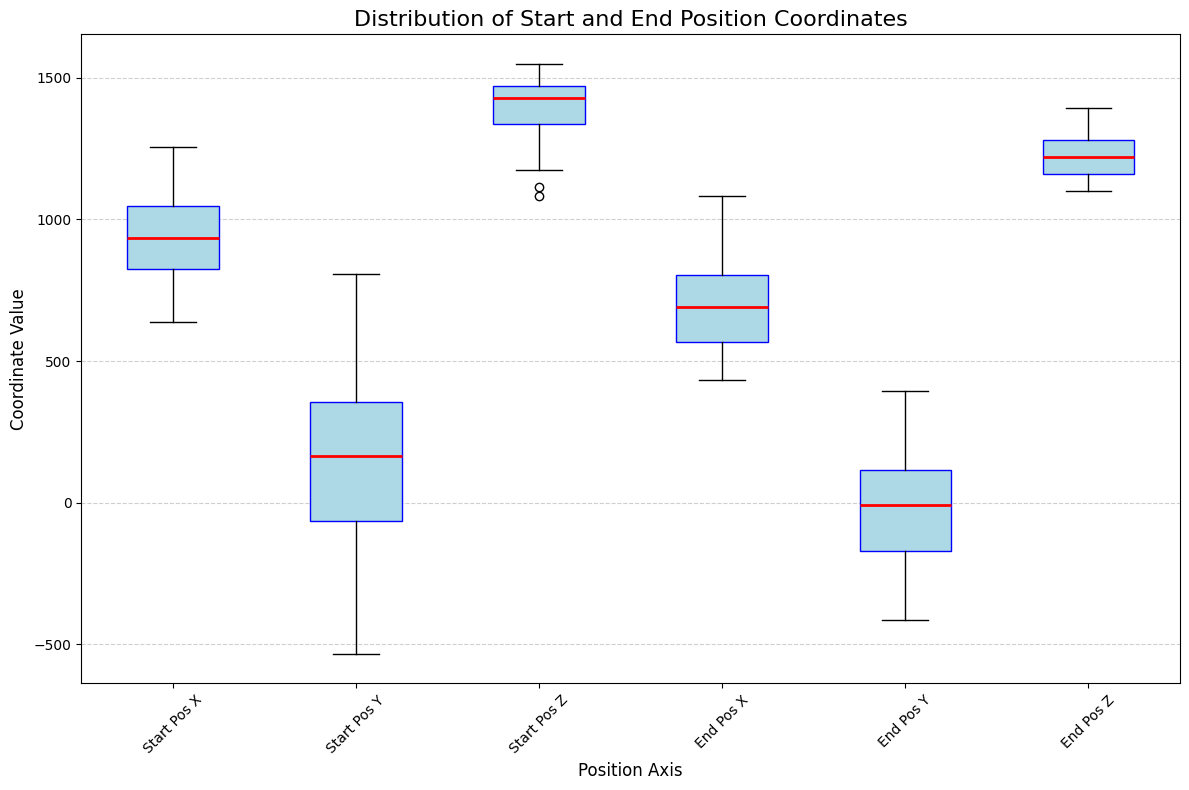

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. result 리스트를 Pandas DataFrame으로 변환합니다.
df_result = pd.DataFrame(result)

# 2. 'start_position'과 'end_position' 열(column)을 각각 X, Y, Z 열로 분리합니다.
# .tolist()를 사용하면 리스트 형태의 데이터를 효율적으로 분리할 수 있습니다.
start_coords = pd.DataFrame(df_result['start_position'].tolist(), columns=['Start Pos X', 'Start Pos Y', 'Start Pos Z'])
end_coords = pd.DataFrame(df_result['end_position'].tolist(), columns=['End Pos X', 'End Pos Y', 'End Pos Z'])

# 3. 시각화에 사용할 DataFrame을 하나로 합칩니다.
plot_df = pd.concat([start_coords, end_coords], axis=1)

# 4. Box Plot을 생성합니다.
plt.style.use('default') # 스타일 초기화
plt.figure(figsize=(12, 8)) # 그래프 크기 조절

# DataFrame을 직접 전달하여 6개의 박스플롯을 한 번에 그립니다.
plt.boxplot(plot_df.values, labels=plot_df.columns, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'),
            medianprops=dict(color='red', linewidth=2))

# 5. 그래프 제목 및 라벨 설정
plt.title('Distribution of Start and End Position Coordinates', fontsize=16)
plt.ylabel('Coordinate Value', fontsize=12)
plt.xlabel('Position Axis', fontsize=12)
plt.xticks(rotation=45) # X축 라벨이 겹치지 않도록 45도 회전
plt.grid(True, axis='y', linestyle='--', alpha=0.6) # Y축 그리드 추가

# 6. 그래프를 이미지 파일로 저장하고 출력합니다.
plt.tight_layout() # 레이아웃 최적화
# plt.savefig("position_distribution_boxplot.png")
print("Box plot이 'position_distribution_boxplot.png' 파일로 저장되었습니다.")
# plt.show() # .ipynb 환경에서는 이 줄이 없어도 그래프가 표시됩니다.

# Bias 설정

In [54]:
# main 실행 코드

# 경로 설정
BVH_FILE_PATH = '/home/maeng/In-HARD/Online/Skeleton/P01_R01.bvh'
MAPPING_CSV_PATH = "/home/maeng/In-HARD/Online/InHARD.csv"
FILE_ID = "P01_R01"

# 각 신체 부위의 좌표 컬럼을 정의합니다.
hips_cols = ['Hips_Xposition', 'Hips_Yposition', 'Hips_Zposition']
left_hand_cols = ['LeftHand_Xposition', 'LeftHand_Yposition', 'LeftHand_Zposition']
right_hand_cols = ['RightHand_Xposition', 'RightHand_Yposition', 'RightHand_Zposition']

# pymo 데이터 접근
parser = BVHParser()
parsed_data = parser.parse(BVH_FILE_PATH)
mapping_df = pd.read_csv(MAPPING_CSV_PATH)

# Picking in front, 7번은 Picking left 데이터만 추출
cond = mapping_df['File'] == FILE_ID
cond2 = mapping_df['Meta_action_class_number'].isin([6, 7]) # 6번은 Picking in front, 7번은 Picking left
filtered_df = mapping_df[cond&cond2]

# iterrows 로 각 Action 마다 반복
result = list()

# bias 설정
x_bias = -300
y_bias = 0
z_bias = -1000

for i, row in filtered_df.iterrows():
    # print(f"{row.Action_start_bvh_frame=}, {row.Action_end_bvh_frame=}")
    start_bvh_frame = row.Action_start_bvh_frame
    end_bvh_frame= row.Action_end_bvh_frame

    start_position, end_position = get_pick_place_position(start_bvh_frame, end_bvh_frame, parsed_data)

    # change_position_for_robodk 적용
    start_position = change_position_for_robodk(start_position, x_bias, y_bias, z_bias)
    end_position = change_position_for_robodk(end_position, x_bias, y_bias, z_bias)
    
    result.append({"start_position":start_position, "end_position":end_position, "Meta_action_class_number":row.Meta_action_class_number, "Meta_action_label":row.Meta_action_label, "Action_label":row.Action_label, "Action_start_rgb_frame":row.Action_start_rgb_frame, "Action_end_rgb_frame":row.Action_end_rgb_frame, "Action_start_rgb_sec":row.Action_start_rgb_sec, "Action_end_rgb_sec":row.Action_end_rgb_sec, "Action_start_bvh_frame":row.Action_start_bvh_frame, "Action_end_bvh_frame":row.Action_end_bvh_frame
})
    print(f'{start_position=}, {end_position=}')
    # break # 1개 데이터 테스트하기 위함

start_position=array([458.32309584, 689.739831  , 500.53623079]), end_position=array([166.27487785, 349.08770306, 152.80384724])
start_position=array([546.10277098, 375.82270219, 434.99863856]), end_position=array([132.05482154, 281.75688682, 242.72735521])
start_position=array([339.34429504, 808.68373736, 352.80668306]), end_position=array([281.09428672, 246.25283376, 189.35345421])
start_position=array([414.54186945, 637.55273068, 549.62904722]), end_position=array([135.80184927, 172.06750057, 154.7078979 ])
start_position=array([342.07348088, 732.38858815, 354.76877811]), end_position=array([256.00622997, 395.83146804, 107.34736454])
start_position=array([561.78211663, 366.25910335, 463.64244196]), end_position=array([261.75061654, 158.34192584, 313.33731111])
start_position=array([514.05914692, 471.69609557, 516.20053741]), end_position=array([386.42558322, 342.58066235, 293.66578303])
start_position=array([643.93271263, -66.52307819, 174.51188256]), end_position=array([235.1518987

Box plot이 'position_distribution_boxplot.png' 파일로 저장되었습니다.


/tmp/ipykernel_25995/2921967832.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_df.values, labels=plot_df.columns, patch_artist=True,


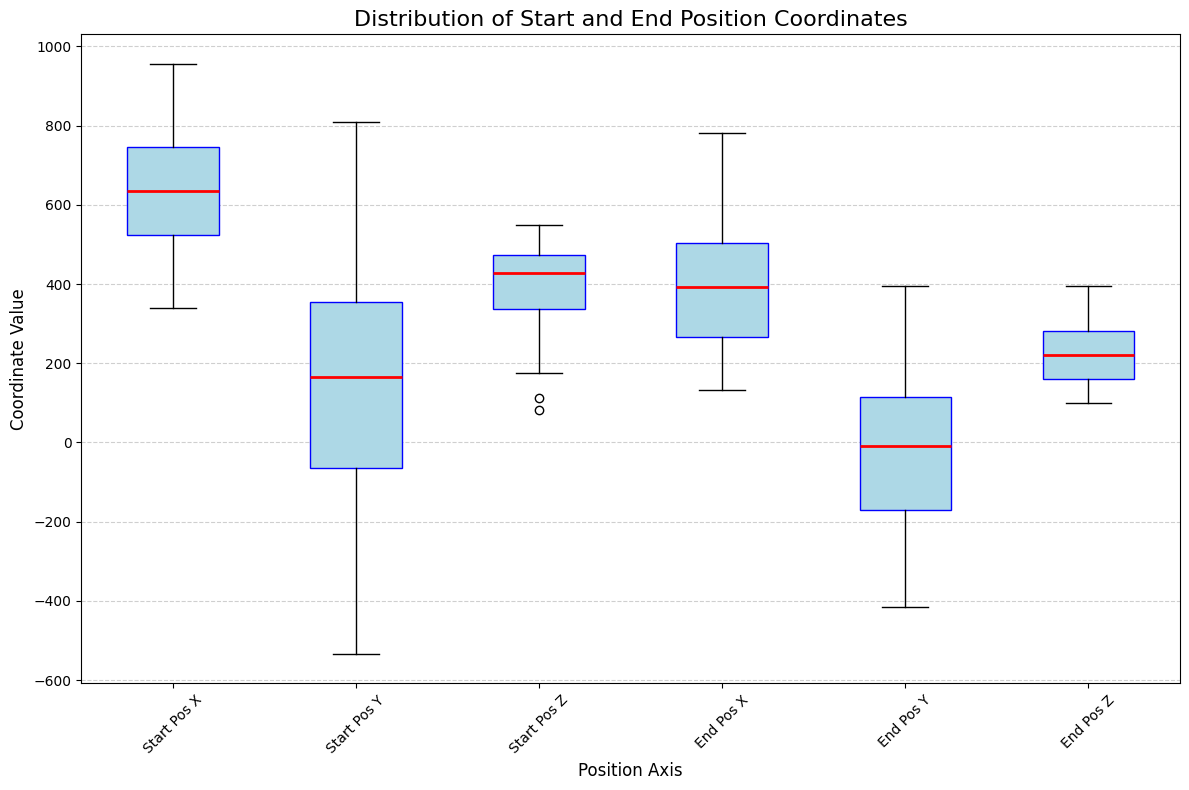

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. result 리스트를 Pandas DataFrame으로 변환합니다.
df_result = pd.DataFrame(result)

# 2. 'start_position'과 'end_position' 열(column)을 각각 X, Y, Z 열로 분리합니다.
# .tolist()를 사용하면 리스트 형태의 데이터를 효율적으로 분리할 수 있습니다.
start_coords = pd.DataFrame(df_result['start_position'].tolist(), columns=['Start Pos X', 'Start Pos Y', 'Start Pos Z'])
end_coords = pd.DataFrame(df_result['end_position'].tolist(), columns=['End Pos X', 'End Pos Y', 'End Pos Z'])

# 3. 시각화에 사용할 DataFrame을 하나로 합칩니다.
plot_df = pd.concat([start_coords, end_coords], axis=1)

# 4. Box Plot을 생성합니다.
plt.style.use('default') # 스타일 초기화
plt.figure(figsize=(12, 8)) # 그래프 크기 조절

# DataFrame을 직접 전달하여 6개의 박스플롯을 한 번에 그립니다.
plt.boxplot(plot_df.values, labels=plot_df.columns, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'),
            medianprops=dict(color='red', linewidth=2))

# 5. 그래프 제목 및 라벨 설정
plt.title('Distribution of Start and End Position Coordinates', fontsize=16)
plt.ylabel('Coordinate Value', fontsize=12)
plt.xlabel('Position Axis', fontsize=12)
plt.xticks(rotation=45) # X축 라벨이 겹치지 않도록 45도 회전
plt.grid(True, axis='y', linestyle='--', alpha=0.6) # Y축 그리드 추가

# 6. 그래프를 이미지 파일로 저장하고 출력합니다.
plt.tight_layout() # 레이아웃 최적화
# plt.savefig("position_distribution_boxplot.png")
print("Box plot이 'position_distribution_boxplot.png' 파일로 저장되었습니다.")
# plt.show() # .ipynb 환경에서는 이 줄이 없어도 그래프가 표시됩니다.

In [56]:
plot_df.describe()

,Start Pos X,Start Pos Y,Start Pos Z,End Pos X,End Pos Y,End Pos Z
count,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000
mean,638.748703,156.937420,397.691287,395.015653,-27.797020,228.093290
std,160.440222,307.748880,115.512017,162.140653,218.272945,80.583613
min,339.344295,-533.122953,81.533392,132.054822,-414.632759,100.535159
25%,524.571012,-64.606428,337.009298,266.586534,-171.437514,160.563129
50%,634.754205,166.193469,428.092531,391.740077,-9.677514,220.559214
75%,746.003030,355.083038,472.577294,504.395938,113.749113,281.212444
max,955.947893,808.683737,549.629047,782.458393,395.831468,395.060842
